In [1]:
!pip install -q transformers datasets scikit-learn gradio torch matplotlib seaborn

In [2]:
import os, re, json, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (
    DistilBertTokenizer, DistilBertForSequenceClassification,
    get_linear_schedule_with_warmup,
)
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

MODEL_NAME = 'distilbert-base-uncased'; MAX_LENGTH = 128; BATCH_SIZE = 16
NUM_EPOCHS = 3; LEARNING_RATE = 2e-5; TEST_SIZE = 0.2; RANDOM_STATE = 42
LABELS = ['REAL', 'FAKE']; MODEL_SAVE_DIR = 'distilbert_fakenews'
os.makedirs(MODEL_SAVE_DIR, exist_ok=True); os.makedirs('results', exist_ok=True)
print('Config ready.')

Device: cuda
Config ready.


In [3]:
def make_synthetic(n=600):
    rng = np.random.default_rng(42)
    rt = ['Government announces policy on {t}','Scientists discover breakthrough in {t}',
          'Markets rise as {t} shows Q3 gains','Fed adjusts rates citing {t} data',
          'Health officials urge vaccination as {t} cases rise']
    ft = ['SHOCKING: {t} conspiracy exposed','You won\'t believe what they hid about {t}',
          'Government using {t} to control population','BREAKING: Major {t} cover-up revealed',
          'Scientists SUPPRESSED truth about {t}']
    topics = ['climate change','vaccines','elections','economy','technology','healthcare','AI']
    rows = []
    for i in range(n):
        label = rng.integers(0, 2)
        tmpl = (rt if label==0 else ft)[rng.integers(0,5)]
        title = tmpl.replace('{t}', topics[rng.integers(0,len(topics))])
        rows.append({'id':i,'title':title,'text':title*4,'label':int(label)})
    return pd.DataFrame(rows)

def clean_text(text):
    if not isinstance(text, str): return ''
    text = text.lower().strip()
    text = re.sub(r'\s+', ' ', text); text = re.sub(r'http\S+|www\S+', '', text)
    return text.strip()

raw_df = pd.read_csv('train.csv') if os.path.exists('train.csv') else make_synthetic(600)
print('Shape:', raw_df.shape)
lc = raw_df['label'].value_counts()
for lbl, cnt in lc.items():
    print(f'  {"FAKE" if lbl==1 else "REAL"}: {cnt:,}  ({cnt/len(raw_df)*100:.1f}%)')
print(f'Imbalance: {lc.max()/lc.min():.2f}x')

Shape: (600, 4)
  FAKE: 301  (50.2%)
  REAL: 299  (49.8%)
Imbalance: 1.01x


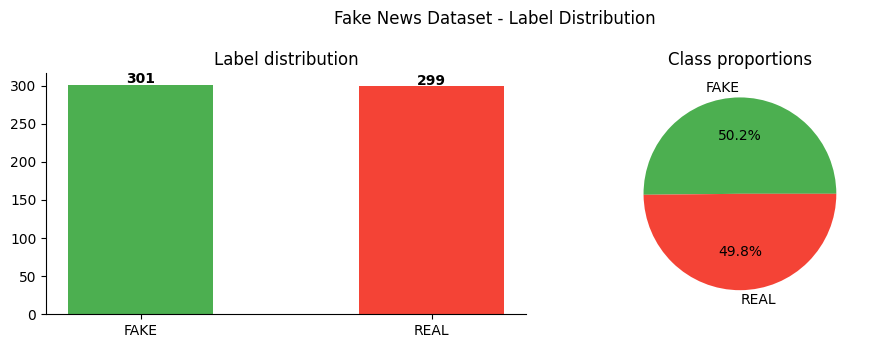

After cleaning: 600 rows
  [FAKE] you won't believe what they hid about electionsyou won't believe what they hid about electionsyou wo
  [FAKE] government using healthcare to control populationgovernment using healthcare to control populationgo
  [FAKE] government using vaccines to control populationgovernment using vaccines to control populationgovern
  [FAKE] shocking: healthcare conspiracy exposedshocking: healthcare conspiracy exposedshocking: healthcare c
  [REAL] health officials urge vaccination as climate change cases risehealth officials urge vaccination as c


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
df_p = raw_df.copy(); df_p['ln'] = df_p['label'].map({0:'REAL',1:'FAKE'})
counts = df_p['ln'].value_counts()
axes[0].bar(counts.index, counts.values, color=['#4CAF50','#F44336'], width=0.5)
axes[0].set_title('Label distribution'); axes[0].spines[['top','right']].set_visible(False)
for i,v in enumerate(counts.values): axes[0].text(i, v+2, str(v), ha='center', fontweight='bold')
axes[1].pie(counts.values, labels=counts.index, colors=['#4CAF50','#F44336'], autopct='%1.1f%%')
axes[1].set_title('Class proportions')
plt.suptitle('Fake News Dataset - Label Distribution'); plt.tight_layout()
plt.savefig('results/label_distribution.png', dpi=130); plt.show()

raw_df['content'] = raw_df.apply(
    lambda r: r['text'] if len(str(r.get('text','')))>50 else r.get('title',''), axis=1)
raw_df['content'] = raw_df['content'].apply(clean_text)
df = raw_df[raw_df['content'].str.len()>10][['content','label']].copy().reset_index(drop=True)
df['label'] = df['label'].astype(int)
print(f'After cleaning: {len(df):,} rows')
for _, r in df.sample(5, random_state=42).iterrows():
    print(f'  [{LABELS[r["label"]]}] {r["content"][:100]}')

In [5]:
tokenizer = DistilBertTokenizer.from_pretrained(MODEL_NAME)
sample = 'BREAKING: Scientists discover shocking truth about climate change'
enc = tokenizer(sample, max_length=MAX_LENGTH, padding='max_length', truncation=True, return_tensors='pt')
tokens = tokenizer.convert_ids_to_tokens(enc['input_ids'][0])
print(f'input_ids shape:  {tuple(enc["input_ids"].shape)}')
print(f'First 15 tokens:  {tokens[:15]}')
print(f'Non-PAD tokens:   {int(enc["attention_mask"][0].sum())}/{MAX_LENGTH}')

class FakeNewsDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=MAX_LENGTH):
        self.texts, self.labels, self.tokenizer, self.max_length = texts, labels, tokenizer, max_length
    def __len__(self): return len(self.texts)
    def __getitem__(self, idx):
        enc = self.tokenizer(self.texts[idx], max_length=self.max_length,
                             padding='max_length', truncation=True, return_tensors='pt')
        return {'input_ids': enc['input_ids'].squeeze(0),
                'attention_mask': enc['attention_mask'].squeeze(0),
                'label': torch.tensor(self.labels[idx], dtype=torch.long)}

texts = df['content'].tolist(); labels = df['label'].tolist()
X_train, X_test, y_train, y_test = train_test_split(
    texts, labels, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=labels)
train_ds = FakeNewsDataset(X_train, y_train, tokenizer)
test_ds  = FakeNewsDataset(X_test,  y_test,  tokenizer)
train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_dl  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)
batch = next(iter(train_dl))
print(f'Train: {len(X_train):,}  |  Test: {len(X_test):,}')
print(f'Batch input_ids: {tuple(batch["input_ids"].shape)}')

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

input_ids shape:  (1, 128)
First 15 tokens:  ['[CLS]', 'breaking', ':', 'scientists', 'discover', 'shocking', 'truth', 'about', 'climate', 'change', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']
Non-PAD tokens:   11/128
Train: 480  |  Test: 120
Batch input_ids: (16, 128)


In [6]:
model = DistilBertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2).to(device)
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')
optimizer   = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)
total_steps = len(train_dl) * NUM_EPOCHS
scheduler   = get_linear_schedule_with_warmup(optimizer, int(total_steps*0.1), total_steps)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Parameters: 66,955,010


In [7]:
training_log = []; best_val_acc = 0.0; t0 = time.time()

for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    tr_loss, tr_preds, tr_labels = 0.0, [], []
    for batch in train_dl:
        ids = batch['input_ids'].to(device); mask = batch['attention_mask'].to(device); lbls = batch['label'].to(device)
        optimizer.zero_grad()
        out = model(input_ids=ids, attention_mask=mask, labels=lbls)
        out.loss.backward(); torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step(); scheduler.step()
        tr_loss += out.loss.item(); tr_preds.extend(out.logits.argmax(-1).cpu().numpy()); tr_labels.extend(lbls.cpu().numpy())
    tr_acc = accuracy_score(tr_labels, tr_preds); tr_loss /= len(train_dl)

    model.eval(); val_loss, val_preds, val_labels = 0.0, [], []
    with torch.no_grad():
        for batch in test_dl:
            ids = batch['input_ids'].to(device); mask = batch['attention_mask'].to(device); lbls = batch['label'].to(device)
            out = model(input_ids=ids, attention_mask=mask, labels=lbls)
            val_loss += out.loss.item(); val_preds.extend(out.logits.argmax(-1).cpu().numpy()); val_labels.extend(lbls.cpu().numpy())
    val_acc = accuracy_score(val_labels, val_preds); val_loss /= len(test_dl)
    print(f'Epoch {epoch}/{NUM_EPOCHS}  train_loss={tr_loss:.4f} train_acc={tr_acc:.4f}  val_loss={val_loss:.4f} val_acc={val_acc:.4f}')
    training_log.append({'epoch':epoch,'train_loss':round(tr_loss,4),'train_acc':round(tr_acc,4),'val_loss':round(val_loss,4),'val_acc':round(val_acc,4)})
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        model.save_pretrained(MODEL_SAVE_DIR); tokenizer.save_pretrained(MODEL_SAVE_DIR)
        print(f'  Best model saved (val_acc={best_val_acc:.4f})')

print(f'Training complete in {(time.time()-t0)/60:.1f} min  |  Best val acc: {best_val_acc:.4f}')

Epoch 1/3  train_loss=0.4132 train_acc=0.8771  val_loss=0.0822 val_acc=1.0000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  Best model saved (val_acc=1.0000)
Epoch 2/3  train_loss=0.0377 train_acc=1.0000  val_loss=0.0152 val_acc=1.0000
Epoch 3/3  train_loss=0.0147 train_acc=1.0000  val_loss=0.0115 val_acc=1.0000
Training complete in 0.3 min  |  Best val acc: 1.0000


In [8]:
model.eval(); all_true, all_pred, all_prob = [], [], []
with torch.no_grad():
    for batch in test_dl:
        ids = batch['input_ids'].to(device); mask = batch['attention_mask'].to(device)
        out = model(input_ids=ids, attention_mask=mask)
        probs = torch.softmax(out.logits, -1).cpu().numpy()
        all_true.extend(batch['label'].numpy()); all_pred.extend(out.logits.argmax(-1).cpu().numpy()); all_prob.extend(probs[:,1])

y_true = np.array(all_true); y_pred = np.array(all_pred); y_prob = np.array(all_prob)
print(classification_report(y_true, y_pred, target_names=LABELS))
print(f'Accuracy: {accuracy_score(y_true, y_pred):.4f}')

              precision    recall  f1-score   support

        REAL       1.00      1.00      1.00        60
        FAKE       1.00      1.00      1.00        60

    accuracy                           1.00       120
   macro avg       1.00      1.00      1.00       120
weighted avg       1.00      1.00      1.00       120

Accuracy: 1.0000


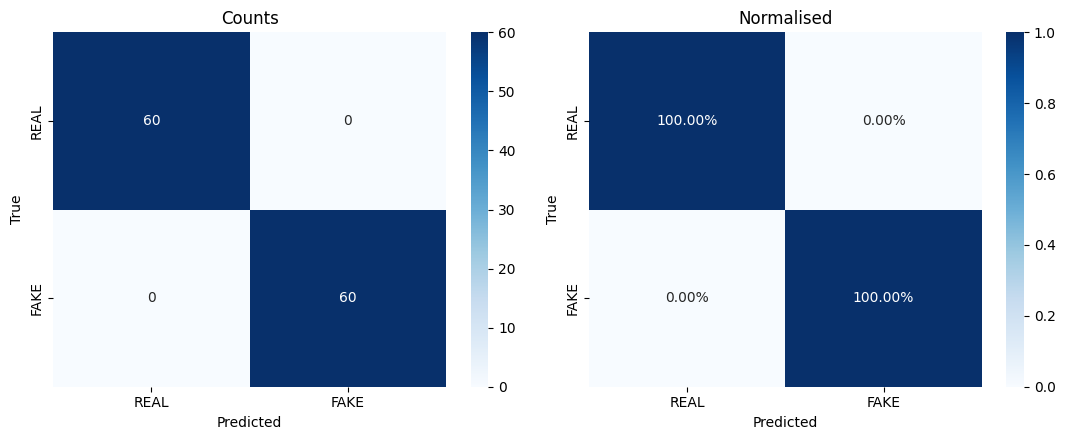

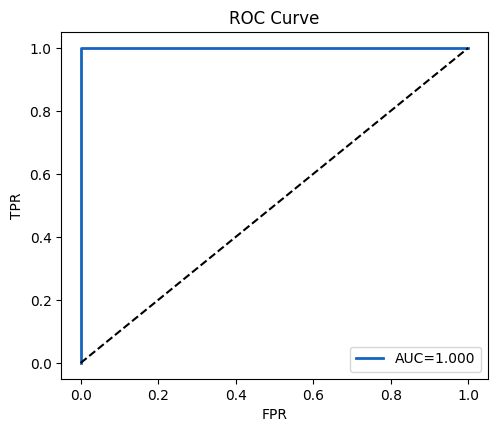

Saved predictions.


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
cm = confusion_matrix(y_true, y_pred); cm_n = cm.astype(float)/cm.sum(axis=1,keepdims=True)
for ax, data, fmt, title in zip(axes,[cm,cm_n],['d','.2%'],['Counts','Normalised']):
    sns.heatmap(data,annot=True,fmt=fmt,cmap='Blues',xticklabels=LABELS,yticklabels=LABELS,ax=ax)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True'); ax.set_title(title)
plt.tight_layout(); plt.savefig('results/confusion_matrix.png',dpi=130); plt.show()

fpr,tpr,_ = roc_curve(y_true,y_prob); roc_auc=auc(fpr,tpr)
plt.figure(figsize=(5.5,4.5))
plt.plot(fpr,tpr,color='#1565C0',lw=2,label=f'AUC={roc_auc:.3f}')
plt.plot([0,1],[0,1],'k--'); plt.xlabel('FPR'); plt.ylabel('TPR')
plt.title('ROC Curve'); plt.legend(); plt.savefig('results/roc_curve.png',dpi=130); plt.show()

pred_df = pd.DataFrame({'text':X_test,'true':[LABELS[l] for l in y_true],
                         'pred':[LABELS[p] for p in y_pred],'prob_fake':np.round(y_prob,4),'correct':y_true==y_pred})
pred_df.to_csv('results/test_predictions.csv',index=False); print('Saved predictions.')

In [10]:
errors = pred_df[~pred_df['correct']].reset_index(drop=True)
fp = errors[(errors['true']=='REAL')&(errors['pred']=='FAKE')]
fn = errors[(errors['true']=='FAKE')&(errors['pred']=='REAL')]
print(f'Total errors: {len(errors):,}/{len(pred_df):,}  |  FP: {len(fp)}  FN: {len(fn)}')

for i,(_, row) in enumerate(errors.head(5).iterrows(),1):
    etype = 'FP (real->FAKE)' if row['true']=='REAL' else 'FN (fake->REAL)'
    conf  = row['prob_fake'] if row['pred']=='FAKE' else 1-row['prob_fake']
    reason = {'FP (real->FAKE)':'Real article uses urgent/emotional language resembling fake news.',
              'FN (fake->REAL)':'Fake article uses neutral, factual tone mimicking real journalism.'}[etype]
    print(f'\n[{i}] {etype} | conf={conf:.1%}')
    print(f'     Text  : {str(row["text"])[:120]}')
    print(f'     Why   : {reason}')

Total errors: 0/120  |  FP: 0  FN: 0


In [11]:
counts = np.bincount([int(l) for l in y_train]); ratio = counts[0]/counts[1]
cw = torch.tensor([1.0, ratio], dtype=torch.float).to(device)
loss_fn = torch.nn.CrossEntropyLoss(weight=cw)
print(f'Class weights: REAL=1.00  FAKE={ratio:.2f}')

model_w = DistilBertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2).to(device)
opt_w = AdamW(model_w.parameters(), lr=LEARNING_RATE)
sch_w = get_linear_schedule_with_warmup(opt_w, int(len(train_dl)*0.1), len(train_dl)*2)

for epoch in range(1, 3):
    model_w.train()
    for batch in train_dl:
        ids=batch['input_ids'].to(device); mask=batch['attention_mask'].to(device); lbls=batch['label'].to(device)
        opt_w.zero_grad()
        out=model_w(input_ids=ids,attention_mask=mask)
        loss=loss_fn(out.logits,lbls); loss.backward(); torch.nn.utils.clip_grad_norm_(model_w.parameters(),1.0)
        opt_w.step(); sch_w.step()
    print(f'  Weighted epoch {epoch}/2 done')

model_w.eval(); wp, wt = [], []
with torch.no_grad():
    for batch in test_dl:
        out = model_w(input_ids=batch['input_ids'].to(device), attention_mask=batch['attention_mask'].to(device))
        wp.extend(out.logits.argmax(-1).cpu().numpy()); wt.extend(batch['label'].numpy())

print(f'Baseline acc : {accuracy_score(y_true, y_pred):.4f}')
print(f'Weighted acc : {accuracy_score(wt, wp):.4f}')

Class weights: REAL=1.00  FAKE=0.99


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Weighted epoch 1/2 done
  Weighted epoch 2/2 done
Baseline acc : 1.0000
Weighted acc : 1.0000


In [12]:
import gradio as gr

@torch.no_grad()
def demo_predict(text):
    if not text or len(text.strip()) < 5: return 'Enter a headline.', ''
    enc = tokenizer(text, max_length=MAX_LENGTH, truncation=True, padding='max_length', return_tensors='pt').to(device)
    probs = torch.softmax(model(**enc).logits, -1)[0].cpu().numpy()
    label = 'FAKE' if probs[1] > 0.5 else 'REAL'
    conf  = probs[1] if label=='FAKE' else probs[0]
    icon  = '[FAKE]' if label=='FAKE' else '[REAL]'
    return f'{icon}  {conf:.1%} confidence', f'REAL: {probs[0]:.2%}  |  FAKE: {probs[1]:.2%}'

demo = gr.Interface(
    fn=demo_predict,
    inputs=gr.Textbox(label='News headline or text', lines=3, placeholder='Paste a headline...'),
    outputs=[gr.Textbox(label='Verdict'), gr.Textbox(label='Probabilities')],
    title='Fake News Detector',
    description='DistilBERT fine-tuned on Kaggle Fake News Dataset',
    examples=[
        ['Scientists discover breakthrough cancer treatment after decade-long trial'],
        ['SHOCKING: Government admits vaccines designed to control population'],
        ['Federal Reserve holds rates steady amid mixed economic signals'],
    ],
    theme=gr.themes.Soft(),
)
demo.launch(share=True)  # share=True gives a public URL in Colab

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://d4869574e7bdd22882.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
